## Set up the experiment

Import QCMet, plotting, and noise-model utilities for the Clifford linear XEB examples.

In [2]:
import sys
from pathlib import Path

workspace_root = Path.cwd()
while not (workspace_root / "pyproject.toml").exists() and workspace_root != workspace_root.parent:
    workspace_root = workspace_root.parent

if not (workspace_root / "pyproject.toml").exists():
    raise FileNotFoundError("Could not locate the QCMet workspace root")

sys.path.insert(0, str(workspace_root))
import matplotlib.pyplot as plt

from qcmet.benchmarks.circuit_execution_quality_metrics.clifford_linear_xeb import CliffordLinearXEB
from qcmet import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error,
)


## Choose experiment parameters

Set the number of qubits, circuit depth, repetitions, and random seed.

In [2]:
n_qubits = 20
depth = 30
num_circuits = 50
seed = 42

## Run a baseline XEB experiment

Generate random Clifford circuits, simulate them, and inspect the mean fidelity.

In [ ]:
experiment = CliffordLinearXEB(
    qubits=n_qubits,
    depth=depth,
    num_circuits=num_circuits,
    seed=seed,
)

experiment.generate_circuits()
experiment.run(
    device=AerSimulator(seed_simulator=seed),
    num_shots=1024
)

print("Mean fidelity should be 1.0 for noiseless simulation and suitably scrambling circuits \n - we thus expect ~ 1 for some random seeded circuit at a reasonable depth")
experiment.analyze()['mean_fidelity']

1.1

## Plot fidelity versus circuit depth

Repeat the experiment for a few noise values

There is an initial scrambling phase, where the fidelity -> 1 as the circuit.

This is the expected result for a perfectly executed circuit.


There is then a second decay phase due to noise, where the fidelity -> 0. This benchmarks the effect of noise.

Running noise=0.001
        Running depth=4
        Running depth=6
        Running depth=8
        Running depth=10
        Running depth=15
        Running depth=30
        Running depth=50


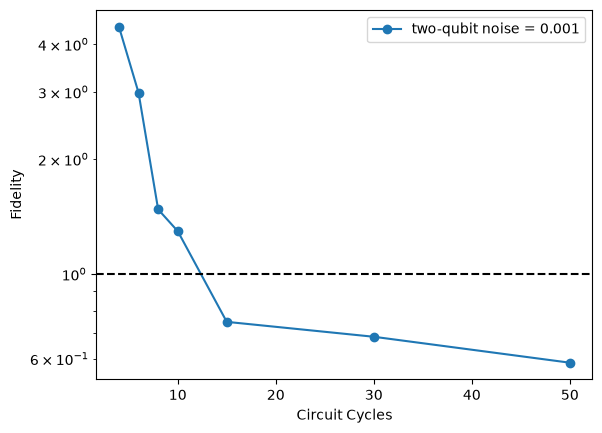

In [ ]:
# Fidelity versus circuit depth for several two-qubit noise levels.
n_qubits = 15
num_circuits = 100
seed = 42

depths = [4, 6, 8, 10, 15, 30, 50]
noise_values = [0., 0.0001, 0.001]
fidelities_by_noise = {}

for noise in noise_values:
    print(f"Running noise={noise}")
    noise_model = NoiseModel()
    error2 = depolarizing_error(noise, 2)
    noise_model.add_all_qubit_quantum_error(error2, ["cz", "cx"])

    fidelities = []
    for depth in depths:
        print(f"        Running depth={depth}")

        noisy_simulator = AerSimulator(
            method="stabilizer",
            max_parallel_experiments=4,
            noise_model=noise_model,
            seed_simulator=seed,
        )

        experiment = CliffordLinearXEB(
            qubits=n_qubits,
            depth=depth,
            num_circuits=num_circuits,
            seed=seed,
        )

        experiment.generate_circuits()
        experiment.run(
            device=noisy_simulator,
            num_shots=300,
        )

        fidelities.append(experiment.analyze()["mean_fidelity"])

    fidelities_by_noise[noise] = fidelities

for noise, fidelities in fidelities_by_noise.items():
    plt.semilogy(depths, fidelities, "o-", label=f"two-qubit noise = {noise}")

plt.axhline(y=1, color="k", linestyle="--")
plt.xlabel("Circuit Cycles")
plt.ylabel("Fidelity")
plt.legend()
plt.show()